# Project 2: Refining stellar stream populations with GNNs

**Dataset:** https://zenodo.org/records/7897840/files/simulated_100_patches.h5

**Grading:**
These projects will be peer-graded using the rubric listed below. 

**Deadline:** 
The project will be due by class time (4pm CT) on **Monday, November 10th**. Please upload a `zip` file to Canvas of the following components: 
- Your completed notebook (`.ipynb` format)
- Your completed notebook (`.html` format)
- A blog post, written in Markdown or any text processor of your choice, that provides motivation, a description of your dataset & methods, and explains the key results in an approachable way.

**Anonymization:**
To facilitate peer review, please ensure your code and your blog post are fully anonymized, but that the folder you upload to Canvas has your name in the filename. Be sure to check that e.g. filepaths or other output in your code cells do not contain your name.

## Project description
In this project, you will work with a dataset consisting of simulated patches of the sky designed to mimic data from the Gaia satellite. Each patch contains a portion of a stellar stream. Below you will find some basic imports and plotting style code as well as instructions on how to load the dataset. Your job is to design an analysis that is able to predict the probability that each star in a new patch of the sky is part of a stream or not.

## Additional resources
- https://zenodo.org/records/7897840
- https://arxiv.org/abs/2305.03761
- https://arxiv.org/abs/2509.08064
- https://pytorch-geometric.readthedocs.io/en/2.6.1/index.html

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### ML-related imports
import torch 
from livelossplot import PlotLosses
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import networkx as nx

### plotting_setup 
%config InlineBackend.figure_format = 'retina'

plt.rcParams['figure.figsize'] = (9,6)

medium_size = 12
large_size = 15

plt.rc('font', size=medium_size)          # default text sizes
plt.rc('xtick', labelsize=medium_size)    # xtick labels
plt.rc('ytick', labelsize=medium_size)    # ytick labels
plt.rc('legend', fontsize=medium_size)    # legend
plt.rc('axes', titlesize=large_size)      # axes title
plt.rc('axes', labelsize=large_size)      # x and y labels
plt.rc('figure', titlesize=large_size)    # figure title

The dataset consists of 100 circular patches of the sky, each containing a handful of stars that represent part of a stellar stream: 

In [2]:
df_all = pd.read_hdf("simulated_100_patches.h5")
df_all

,μ_δ,μ_α,δ,α,b-r,g,ϕ,λ,μ_ϕcosλ,μ_λ,stream,α_wrapped,label,nn_score,file
0,-6.916890,1.189340,56.738241,173.716410,1.116699,19.436199,9.501990,0.467208,2.906244,-6.388399,False,173.716410,1,0.482555,0
1,-9.307770,-1.487510,56.785184,173.616905,0.739000,18.930500,9.437339,0.498815,0.910470,-9.381807,False,173.616905,0,0.488335,0
2,-8.845130,3.498650,56.721386,173.743575,1.346800,18.566999,9.520686,0.454691,5.632414,-7.665037,False,173.743575,1,0.492725,0
3,-6.424980,-4.619740,56.650657,173.776438,2.400400,20.639000,9.556140,0.390884,-2.831004,-7.389708,False,173.776438,1,0.513918,0
4,-8.337630,-3.678160,56.570386,173.611326,0.713100,17.377399,9.488593,0.290198,-1.454926,-8.996006,False,173.611326,0,0.488293,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19941450,-8.749696,0.805843,49.148634,161.634594,0.351167,18.916311,3.588514,-8.207791,1.509347,-8.656121,True,161.634594,1,0.568984,99
19941451,-8.755975,3.088981,69.206825,142.237441,0.266182,20.001095,-5.028055,12.224935,1.198091,-9.207252,True,142.237441,1,0.621607,99
19941452,-8.835673,1.403575,56.402229,156.755774,0.544754,19.585703,0.307596,-1.096513,1.475824,-8.823893,True,156.755774,1,0.604607,99
19941453,-7.845001,0.273714,46.203475,163.205856,1.072615,20.372802,4.934001,-11.041999,1.094437,-7.773105,True,163.205856,0,0.490847,99


Now let's pick the first patch to visualize (note the `file` column): 

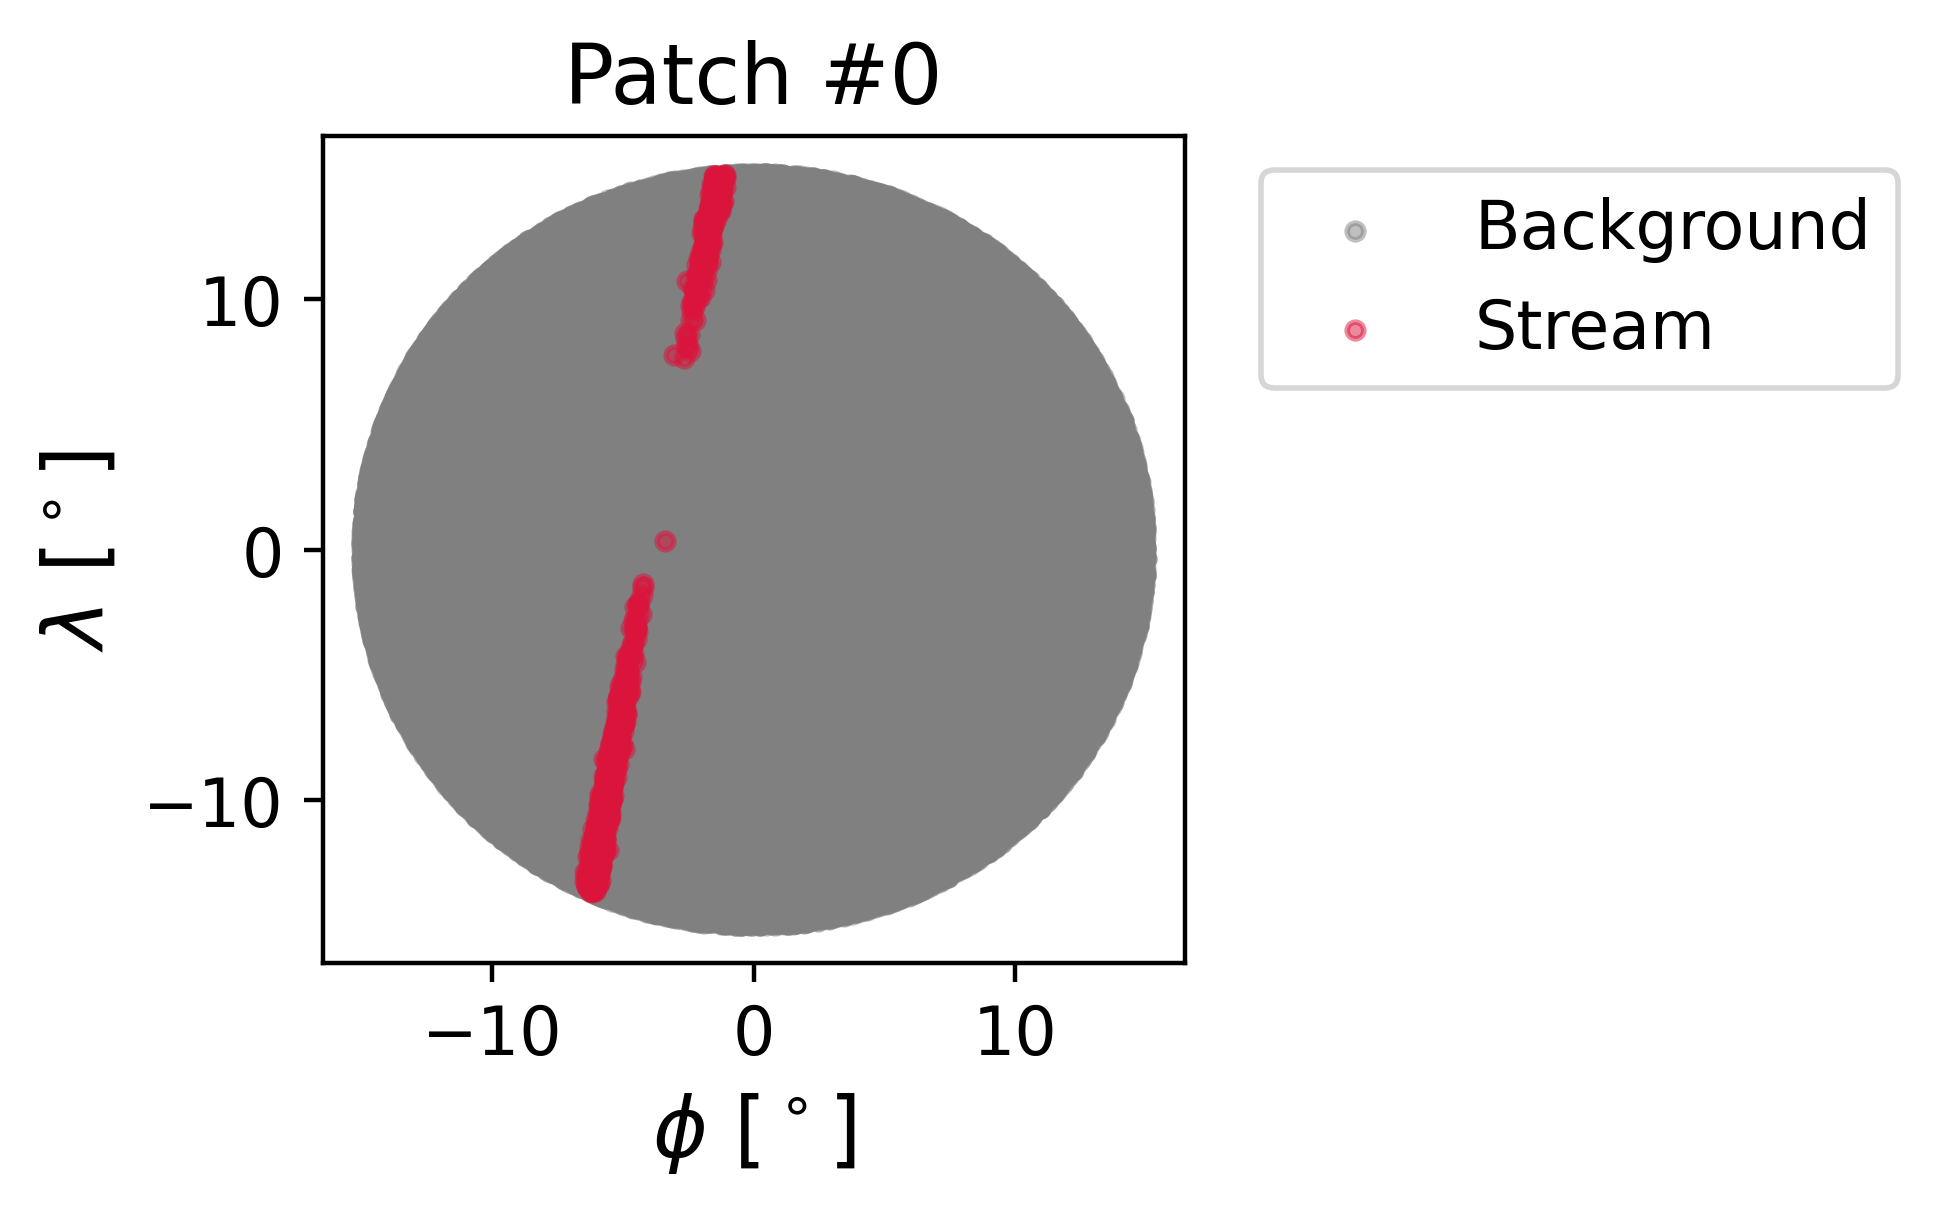

In [3]:
df = df_all[df_all.file == 0] ## select all events with the index "0" listed as their file

plt.figure(dpi=200, figsize=(5,3.2), tight_layout=True)
plt.scatter(df[~df.stream]['ϕ'], df[~df.stream]['λ'], color='grey', alpha=0.5, marker=".", label="Background");
plt.scatter(df[df.stream]['ϕ'], df[df.stream]['λ'], color='crimson', alpha=0.5, marker=".", label="Stream");
plt.xlabel(r"$\phi$ [$^\circ$]")
plt.ylabel(r"$\lambda$ [$^\circ$]");
plt.title(f"Patch #{df.file.unique()[0]}");
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

# First steps: 

### Define which stars to focus on for the classification task:
- Classifying all the stars in the patch is one valid approach, but you might prefer to reduce the dataset size for speed purposes.
- Given the rough location of a known stream, how might you select a subset of stars in the patch to classify? 
- Define a function to return a subset of stars close to the stream for an arbitrary patch, and apply it to Patch #0.
- Make a plot like the one above, but adding your subset of stars as a new color in the plot.

### Preprocess your data as graphs: 
- Create a function that takes a patch as input and returns a Pytorch Geometric graph object (e.g. `Data(x=x, edge_index=edge_index, y=y)`).
    - Define your node features (I recommend `"ϕ", "λ", "μ_ϕcosλ", "μ_λ", 'b-r', 'g'`.)
    - Define your node labels (are they members of the stream or not?)
    - Define your edges (start with no edges at first)
- Use 80 streams for training and 20 for testing, and define DataLoader objects for each.

### Define your model & train
- Define a Graph Convolutional Network (GCN) that processes each graph one at a time and classifies each node (i.e. star) in the graph as stream or not-stream. 
- Define an appropriate loss function & optimizer for this node classification task.
- Train until you reach model convergence.
- Visualize the loss curve.

### Evaluate your model 
- Evaluate your trained model on the test set. How well does your model do at identifying which stars are part of each test stream? One figure-of-merit you can choose is purity, i.e. how many of the stars passing your threshold are actually stream stars?
- Visualize the predictions for each stream alongside a distribution of the NN scores for all stars in the patch. 
- Make a histogram of your chosen figure-of-merit (or figures of merit) that summarizes the performance across all 20 test streams. 

# Next steps: 

Now, try adding edges to each graph. How will you define the edges? Experiment with at least 2 different strategies, and assess the impact on your overall result. 

# Optional / extra credit:
(Up to 1 extra point) 

Try applying your model to at least 1 real patch of Gaia data containing stars from the GD-1 stream, found in the same Zenodo page, and assess your results: https://zenodo.org/records/7897840

---

# Peer Review Grading Rubric

For full credit on this open-ended task, you are expected to: 
- Develop & implement a procedure for applying node classification to stellar streams using GNNs
- Use sufficient documentation in your code for an external reader to understand your methods and why you chose them
- Make sure your code is anonymized
- Write up your results in an anonymized blog post that includes at least one figure.

### You will be graded using the following 5-point rubric:
    - ✅ .ipynb file included
    - ✅ .html file included
    - ✅ Blog post included
    - ✅ Code is complete & well-documented throughout, including the "Next Steps" section, and is fully anonymized
    - ✅ Blog post is easy to read, thoughtfully organized, has at least 1 figure, anonymized, and effectively conveys the key methods & results

For each component of the project, you may earn 0 points, 0.5 points, or 1 point.